# Topic 2 — Transformations
**Covers:** Log transform · Square root · Box-Cox · Yeo-Johnson · Skewness correction ·
Normalization vs. Transformation · Visual diagnostics (Q-Q plots) · Inverse transforms ·
When NOT to transform

**Dataset:** `data/raw/transformations_data.csv` — PrepEdge institute operations data with
columns chosen to have different skew profiles, including one column with **negative
values** (`profit_margin_pct`) specifically so Box-Cox's positive-only limitation is visible.

---
## Descriptions

Imagine you have a lump of playdough shaped like a tall, skinny mountain with a tiny base —
that's a **skewed** shape. It's hard to compare mountains when one is a weird spike and the
others are round hills.

- **Log transform** = squishing the tall spike down gently, like pressing playdough with your
  palm — big numbers get squished a LOT, small numbers barely move. Now it looks like a nice
  round hill.
- **Square root** = a gentler squish than log — good for medium spikes, like counting things
  (how many candies you have).
- **Box-Cox** = a smart robot that TRIES many squishing strengths (log, square root, and
  others) and picks the one that makes your hill the roundest — but it only works if your
  playdough amount is always a positive number (you can't have negative candies!).
- **Yeo-Johnson** = the same smart robot, but it also works even if some of your numbers are
  negative (like "temperature below zero" or "the shop lost money this month").
- **Normalization vs. Transformation** = normalization just resizes your playdough to fit in a
  standard box (like Session 5's scalers) — it doesn't change the SHAPE of the lump.
  Transformation actually reshapes the spike into a round hill. You often need BOTH: reshape
  first, then resize.
- **Inverse transform** = after you squish the playdough down and a robot makes a guess about
  it, you need to UN-squish the guess back to normal size so it makes sense to a person again.

## 1. WHY — Why do we care about skewness?

Many models (linear/logistic regression, and anything that assumes roughly-normal residuals)
perform better when numeric inputs are **not wildly skewed**. A right-skewed column — a few
huge values dragging a long tail — means:
- The mean is pulled away from where "most" data actually sits.
- A few extreme rows can dominate a model's fitted coefficients.
- Distance-based methods over-weight the tail.

Fixing skew doesn't add information — it makes the SAME information easier for a model
(and for you, visually) to work with.

Skewness of each column (roughly 0 = symmetric, >1 = strongly right-skewed):
batch_fee_revenue           1.26
session_duration_minutes    2.79
monthly_queries             0.60
mock_test_avg              -0.04
profit_margin_pct          -0.03
dtype: float64


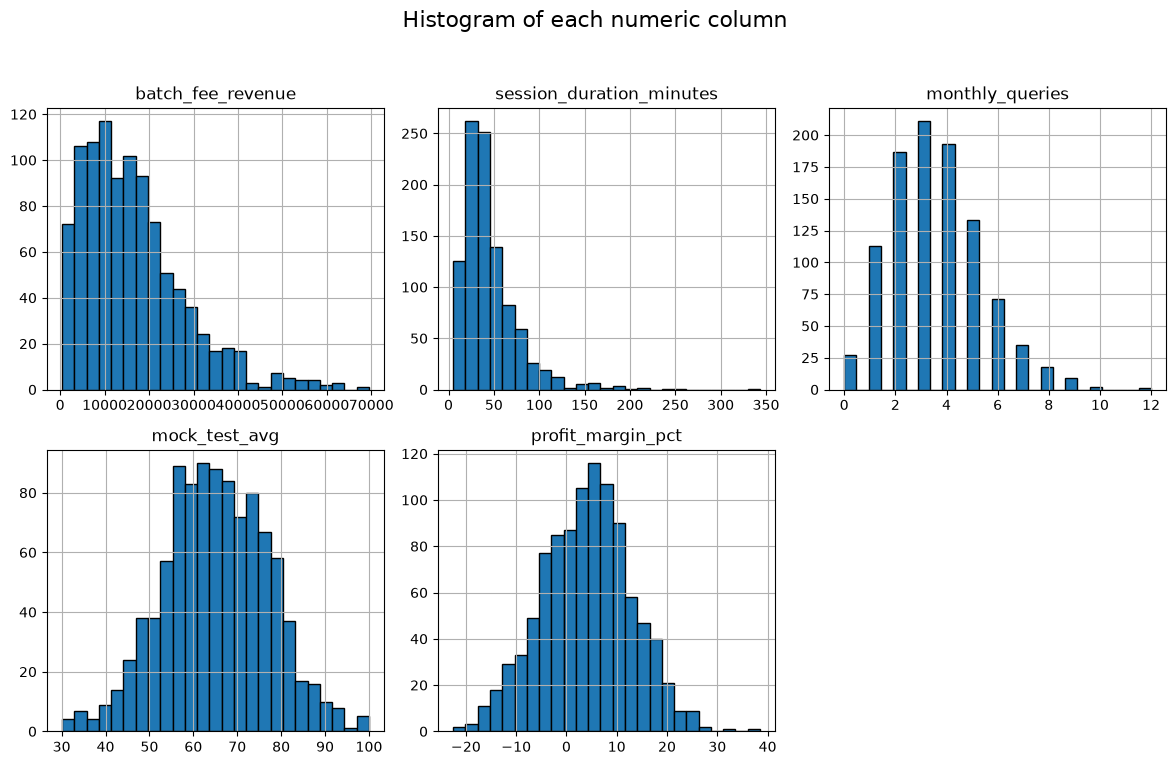

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../datasets/transformations_data.csv")
skew_before = df.drop(columns=["batch_id"]).skew()
print("Skewness of each column (roughly 0 = symmetric, >1 = strongly right-skewed):")
print(skew_before.round(2))

# plot histogram for each numeric column
numeric_df = df.drop(columns=["batch_id"])
numeric_df.hist(figsize=(12, 8), bins=25, layout=(2, 3), edgecolor='black')
plt.suptitle('Histogram of each numeric column', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 2. WHAT — The transformation toolkit

| Transform | Formula | Handles negative values? | Handles zero? | Best for |
|---|---|---|---|---|
| **Log** | `log(x)` or `log(x + 1)` | No (needs x > 0, or x >= 0 with the `+1` trick) | Yes, with `log1p` | Strongly right-skewed, always-positive data (revenue, durations) |
| **Square root** | `sqrt(x)` | No (needs x >= 0) | Yes | Mild right skew, especially count data |
| **Box-Cox** | `(x^λ - 1)/λ` for λ≠0, else `log(x)` — λ chosen automatically | **No — strictly positive only** | No (x must be > 0) | Automatic "best" power transform, when all values > 0 |
| **Yeo-Johnson** | Box-Cox-like, but defined piecewise for x≥0 and x<0 | **Yes** | Yes | Same as Box-Cox, but data includes zero/negative values |

## 3. HOW — Manual log transform (worked example)

Take 3 values from `batch_fee_revenue`-like data: `[1000, 10000, 100000]`

```
log10(1000)   = 3
log10(10000)  = 4
log10(100000) = 5
```

Notice: a 100,000-vs-1,000 gap (99,000 apart) becomes just `5 - 3 = 2` apart after log — the
transform compresses large gaps between big numbers much more than gaps between small numbers.
That's exactly what taming a long right tail requires.

In [2]:
toy = np.array([1000, 10000, 100000])
print("Raw:", toy)
print("log10:", np.log10(toy))
print("natural log (ln):", np.log(toy).round(3))

Raw: [  1000  10000 100000]
log10: [3. 4. 5.]
natural log (ln): [ 6.908  9.21  11.513]


## 4. HOW — Applying each transform in code, and checking skew before/after

Box-Cox chose lambda = 0.0088 automatically


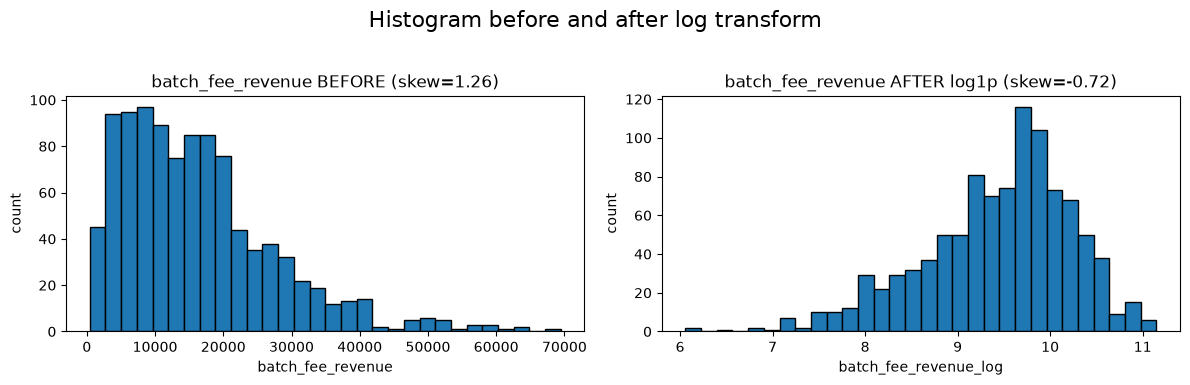

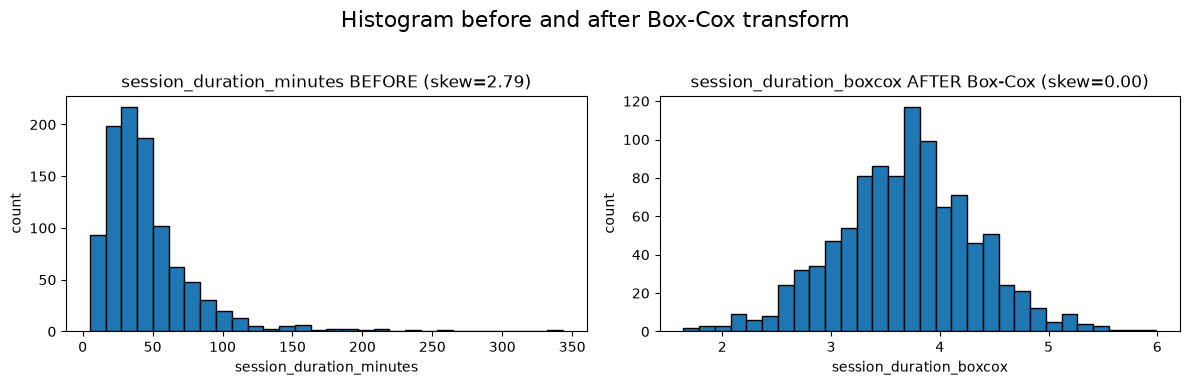


Skew comparison:
                            before  after
batch_fee_revenue (log)      1.260 -0.720
monthly_queries (sqrt)       0.600 -0.623
session_duration (Box-Cox)   2.788  0.001


In [ ]:
from scipy import stats

work = df.copy()

# --- Log transform (log1p handles zero values safely: log(x+1)) ---
work["batch_fee_revenue_log"] = np.log1p(work["batch_fee_revenue"])

# --- Square root ---
work["monthly_queries_sqrt"] = np.sqrt(work["monthly_queries"])

# --- Box-Cox (requires strictly positive values -- session_duration_minutes qualifies) ---
boxcox_vals, boxcox_lambda = stats.boxcox(work["session_duration_minutes"])
work["session_duration_boxcox"] = boxcox_vals
print(f"Box-Cox chose lambda = {boxcox_lambda:.4f} automatically")

# --- Histogram before/after log transform ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["batch_fee_revenue"], bins=30, edgecolor="black")
axes[0].set_title(f"batch_fee_revenue BEFORE (skew={df['batch_fee_revenue'].skew():.2f})")
axes[0].set_xlabel("batch_fee_revenue")
axes[0].set_ylabel("count")

axes[1].hist(work["batch_fee_revenue_log"], bins=30, edgecolor="black")
axes[1].set_title(f"batch_fee_revenue AFTER log1p (skew={work['batch_fee_revenue_log'].skew():.2f})")
axes[1].set_xlabel("batch_fee_revenue_log")
axes[1].set_ylabel("count")


plt.suptitle("Histogram before and after log transform", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nSkew comparison:")
print(pd.DataFrame({
    "before": [df["batch_fee_revenue"].skew(), df["monthly_queries"].skew(), df["session_duration_minutes"].skew()],
    "after":  [work["batch_fee_revenue_log"].skew(), work["monthly_queries_sqrt"].skew(), work["session_duration_boxcox"].skew()],
}, index=["batch_fee_revenue (log)", "monthly_queries (sqrt)", "session_duration (Box-Cox)"]).round(3))

## 5. Visual diagnostic: Q-Q plots — is the data actually closer to normal now?

Skewness (a single number) is a quick check, but a **Q-Q (quantile-quantile) plot** is the
gold-standard visual diagnostic: it plots your data's quantiles against a perfect normal
distribution's quantiles. If the points fall roughly on the diagonal line, the data is
approximately normal; systematic curves away from the line reveal skew or heavy tails.

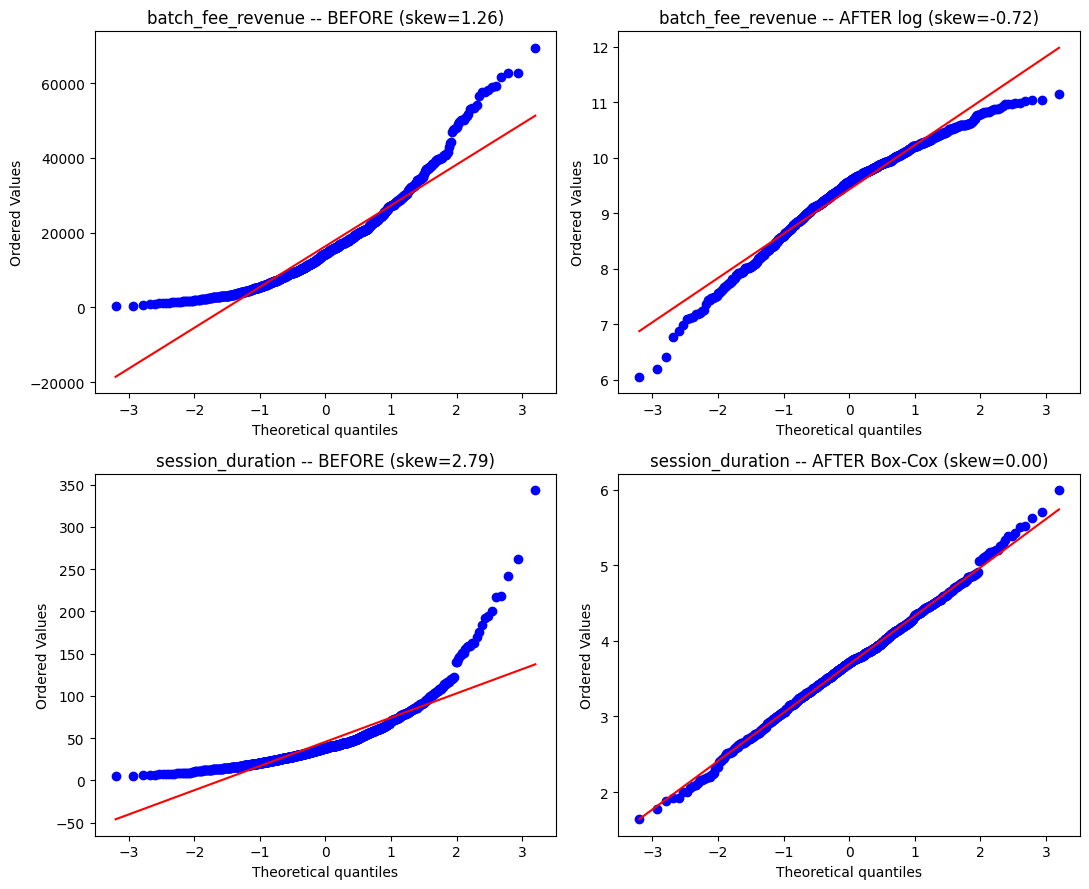

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

stats.probplot(df["batch_fee_revenue"], dist="norm", plot=axes[0, 0])
axes[0, 0].set_title(f"batch_fee_revenue -- BEFORE (skew={df['batch_fee_revenue'].skew():.2f})")

stats.probplot(work["batch_fee_revenue_log"], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title(f"batch_fee_revenue -- AFTER log (skew={work['batch_fee_revenue_log'].skew():.2f})")

stats.probplot(df["session_duration_minutes"], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(f"session_duration -- BEFORE (skew={df['session_duration_minutes'].skew():.2f})")

stats.probplot(work["session_duration_boxcox"], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(f"session_duration -- AFTER Box-Cox (skew={work['session_duration_boxcox'].skew():.2f})")

plt.tight_layout()
plt.show()

**How to read it:** in the "BEFORE" plots, the points curve sharply away from the diagonal
line at the upper end — that curve IS the right-skew, visually. In the "AFTER" plots, the
points hug the diagonal much more closely across the whole range — a direct visual
confirmation that the transform worked, not just a lower skew number.

## 6. The negative-values case: why Box-Cox fails and Yeo-Johnson doesn't

In [5]:
print("profit_margin_pct has negative values:",
      (df["profit_margin_pct"] < 0).sum(), "out of", len(df))

try:
    stats.boxcox(df["profit_margin_pct"])
except ValueError as e:
    print("\nBox-Cox error (as expected):", e)

profit_margin_pct has negative values: 327 out of 1000

Box-Cox error (as expected): Data must be positive.


In [6]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
work["profit_margin_yeojohnson"] = pt.fit_transform(df[["profit_margin_pct"]])

print(f"Yeo-Johnson chosen lambda: {pt.lambdas_[0]:.4f}")
print("Skew before:", df['profit_margin_pct'].skew().round(3))
print("Skew after: ", work['profit_margin_yeojohnson'].skew().round(3))

Yeo-Johnson chosen lambda: 1.0089
Skew before: -0.027
Skew after:  0.019


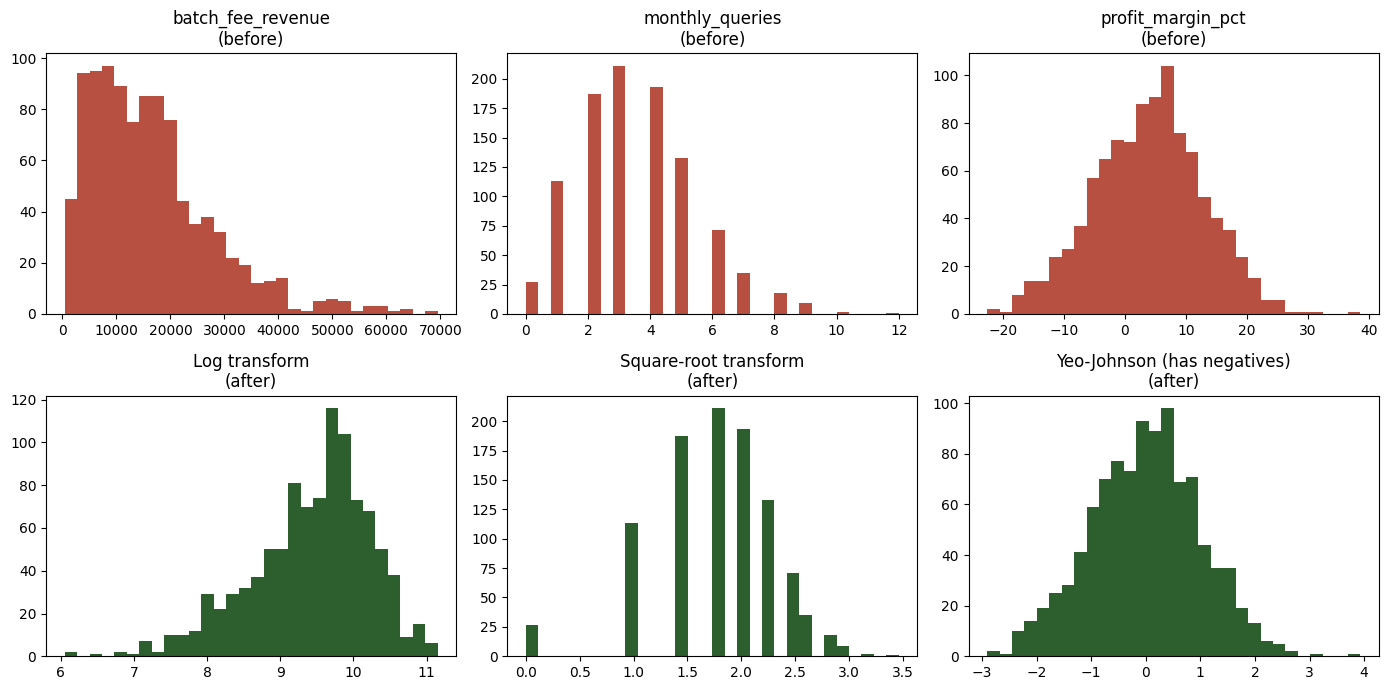

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
pairs = [
    ("batch_fee_revenue", "batch_fee_revenue_log", "Log transform"),
    ("monthly_queries", "monthly_queries_sqrt", "Square-root transform"),
    ("profit_margin_pct", "profit_margin_yeojohnson", "Yeo-Johnson (has negatives)"),
]
for i, (raw_col, trans_col, title) in enumerate(pairs):
    axes[0, i].hist(df[raw_col], bins=30, color="#B85042")
    axes[0, i].set_title(f"{raw_col}\n(before)")
    axes[1, i].hist(work[trans_col], bins=30, color="#2C5F2D")
    axes[1, i].set_title(f"{title}\n(after)")
plt.tight_layout()
plt.show()

## 7. Systematically comparing ALL transforms on one column

Rather than guessing which transform to use, we can compute skew (and a formal normality test
p-value) across every candidate transform and let the data decide — this is essentially what
Box-Cox/Yeo-Johnson automate internally, made explicit here for a positive-only column.

In [8]:
from scipy.stats import shapiro

candidates = {
    "raw": df["batch_fee_revenue"],
    "log1p": np.log1p(df["batch_fee_revenue"]),
    "sqrt": np.sqrt(df["batch_fee_revenue"]),
    "boxcox": pd.Series(stats.boxcox(df["batch_fee_revenue"])[0]),
}

rows = []
for name, series in candidates.items():
    # Shapiro-Wilk normality test: higher p-value = more consistent with a normal distribution
    # (sample for speed -- Shapiro is sensitive/slow on very large n)
    sample = series.sample(min(500, len(series)), random_state=0)
    stat, p = shapiro(sample)
    rows.append({"transform": name, "skew": round(series.skew(), 3), "shapiro_p_value": round(p, 4)})

pd.DataFrame(rows).sort_values("shapiro_p_value", ascending=False)

,transform,skew,shapiro_p_value
3,boxcox,-0.030,0.1306
2,sqrt,0.327,0.0258
1,log1p,-0.720,0.0000
0,raw,1.260,0.0000


**How to read this table:** lower absolute skew AND a higher Shapiro-Wilk p-value both point
toward "more normal-shaped." Box-Cox usually wins this comparison on a positive-only column,
precisely because it searches across a continuum of power transforms (including log and sqrt
as special cases) and picks the best-fitting one automatically.

## 8. Inverse transform — getting predictions back to the original scale

If you transform your TARGET variable (not just a feature) before training — a common trick
when the target itself is skewed — you must **invert** the transform on your model's
predictions before they mean anything to a human stakeholder. Forgetting this step is a classic
practical mistake.

In [9]:
# Suppose we'd modeled log1p(batch_fee_revenue) instead of the raw revenue
log_target = np.log1p(df["batch_fee_revenue"])

# ... after fitting a model and getting a prediction in LOG space, e.g.:
example_log_prediction = log_target.iloc[0]
print(f"Model's raw output (log space): {example_log_prediction:.4f}")

# INVERSE of log1p is expm1 (exp(x) - 1) -- always invert with the exact opposite operation
recovered_value = np.expm1(example_log_prediction)
print(f"Inverted back to real rupees: {recovered_value:,.2f}")
print(f"Actual original value:        {df['batch_fee_revenue'].iloc[0]:,.2f}")

Model's raw output (log space): 9.5245
Inverted back to real rupees: 13,690.00
Actual original value:        13,690.00


In [10]:
# PowerTransformer conveniently provides .inverse_transform() built in
pt_check = PowerTransformer(method="yeo-johnson")
transformed = pt_check.fit_transform(df[["profit_margin_pct"]])
recovered = pt_check.inverse_transform(transformed)

print("Original first 5 values:  ", df["profit_margin_pct"].head().values)
print("Recovered after inverse:  ", recovered[:5].flatten().round(2))
print("(Should match almost exactly -- transform and inverse_transform are designed as a pair)")

Original first 5 values:   [  4.75  16.96  -2.34  -5.22 -13.54]
Recovered after inverse:   [  4.75  16.96  -2.34  -5.22 -13.54]
(Should match almost exactly -- transform and inverse_transform are designed as a pair)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


## 9. Normalization vs. Transformation — not the same thing

- **Transformation** (log, sqrt, Box-Cox, Yeo-Johnson) changes the **shape** of the
  distribution — it can turn a skewed hill into a symmetric one.
- **Normalization/Scaling** (StandardScaler, MinMaxScaler — Session 5 of Unit 1) changes the
  **range/units** of a column, but does NOT fix skew — a skewed column, rescaled, is still
  exactly as skewed, just on a different axis.

**Typical order:** fix skew first (transform), THEN scale if your model needs it
(distance-based / gradient-based models).

In [11]:
from sklearn.preprocessing import StandardScaler

# Scaling alone does NOT fix skew -- same skew value, just re-centered/re-scaled
scaled_only = StandardScaler().fit_transform(df[["batch_fee_revenue"]]).flatten()
print("Skew before scaling:", df['batch_fee_revenue'].skew().round(3))
print("Skew after StandardScaler ONLY (no transform):", pd.Series(scaled_only).skew().round(3))
print("Skew after log transform (from earlier):", work['batch_fee_revenue_log'].skew().round(3))

Skew before scaling: 1.26
Skew after StandardScaler ONLY (no transform): 1.26
Skew after log transform (from earlier): -0.72


## 10. ⚠️ When NOT to transform

Transformations are not a universal default — they cost interpretability and can actively hurt
some models:

- **Tree-based models (Random Forest, XGBoost, Decision Trees)** split on thresholds, and a
  monotonic transform (log, sqrt, Box-Cox, Yeo-Johnson are all monotonic) **doesn't change
  which side of a threshold a point falls on** — so these models get essentially zero benefit
  from transformation, while your feature becomes harder for a human to interpret directly.
- **A column that's already roughly symmetric** (`mock_test_avg` in our dataset, skew ≈ 0)
  gains nothing from transforming, and unnecessarily complicates the pipeline.
- **When interpretability matters more than a small accuracy gain** — a coefficient on
  "log(revenue)" is harder to explain to a non-technical stakeholder than a coefficient on
  "revenue" directly.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

y = df["mock_test_avg"]  # arbitrary target for illustration
X_raw = df[["batch_fee_revenue"]]
X_log = pd.DataFrame({"batch_fee_revenue_log": np.log1p(df["batch_fee_revenue"])})

for name, X in [("Raw (untransformed)", X_raw), ("Log-transformed", X_log)]:
    scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=0), X, y, cv=5, scoring="r2")
    print(f"RandomForest with {name:22s} mean CV R^2 = {scores.mean():.4f}")

RandomForest with Raw (untransformed)    mean CV R^2 = -0.5074


RandomForest with Log-transformed        mean CV R^2 = -0.5051


As expected, a tree-based model's performance is essentially unchanged by the log
transform — confirming that transformation is a tool for skew-sensitive models
(linear/gradient-based), not a universal preprocessing step for every model type.

## 11. Recap

- Skew makes a few extreme values dominate mean-based / gradient-based methods.
- Log & sqrt are simple, manual, interpretable fixes; Box-Cox and Yeo-Johnson automatically
  pick the best power transform.
- Box-Cox needs strictly positive data; Yeo-Johnson works with zero/negative values too.
- Q-Q plots are the most reliable visual check that a transform actually normalized the shape.
- Always keep the inverse transform available if you transformed the TARGET — predictions need
  converting back to the original, human-meaningful scale.
- Scaling (normalization) resizes a distribution; transformation reshapes it — different
  problems, often used together, transform first.
- Tree-based models are largely indifferent to monotonic transforms — don't transform by
  default; transform when the model and the skew both call for it.

**ELI5 recap:** squish the tall spike into a round hill (transform), THEN resize the hill to
fit a standard box (normalize) — resizing alone never fixes the spike shape. And if you ever
squish something down to make a guess, remember to un-squish the guess back to normal size
before showing it to anyone (inverse transform).